In [11]:
import logisticRegression
import importlib
importlib.reload(logisticRegression)
from logisticRegression import LogisticRegression

Here is the link to my source code (source.py): https://github.com/cjy-2001/cjy-2001.github.io/blob/main/posts/optimization-post/logisticRegression.py

## 1. Implement Logistic Regression

In my source file, I've implemented a LogisticRegression() class. It has similar user-facing functions as the Perceptron() class from the previous blog post. These are:

- `LogisticRegression.fit(X, y)` is the primary method. This method has no return value. If LR is a LogisticRegression object, then after `LR.fit(X, y)` is called, LR has an instance variable of weights called w. This w is the vector of weights, including the bias term. LR has an instance variable called LR.loss_history which is a list of the evolution of the loss over the training period (see `LogisticRegression.loss(X, y)` below).
- `LogisticRegression.predict(X)` will return a vector of predicted labels. These are the model’s predictions for the labels on the data.
- `LogisticRegression.score(X, y)` returns the accuracy of the predictions as a number between 0 and 1, with 1 corresponding to perfect classification.
- `LogisticRegression.loss(X, y)` returns the overall loss (empirical risk) of the current weights on X and y.

#### Gradient Descent

At first, I need to have some test data.

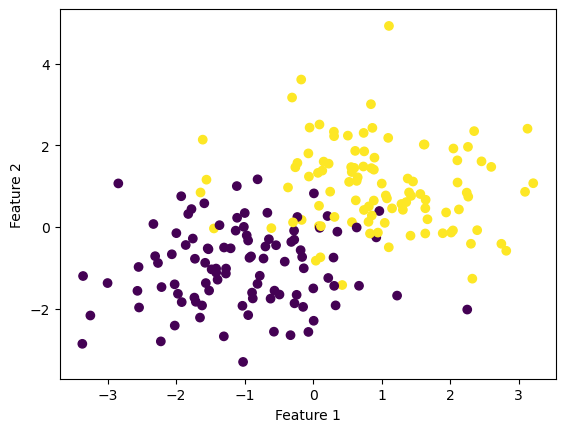

In [12]:
from matplotlib import pyplot as plt
from sklearn.datasets import make_blobs
import numpy as np

np.random.seed(12345)

p_features = 11

X, y = make_blobs(n_samples = 200, n_features = p_features - 1, centers =  [(-1, -1), (1, 1)])

fig = plt.scatter(X[:,0], X[:,1], c = y)
xlab = plt.xlabel("Feature 1")
ylab = plt.ylabel("Feature 2") 

Allow my algorithm to fit the data.

In [13]:
LR = LogisticRegression()
LR.fit(X, y, alpha = 0.05, max_epochs = 1000)

Now we can visualize the resulting classifier and check the value of the loss that it achieves. The graph shows that my classifier converges. 

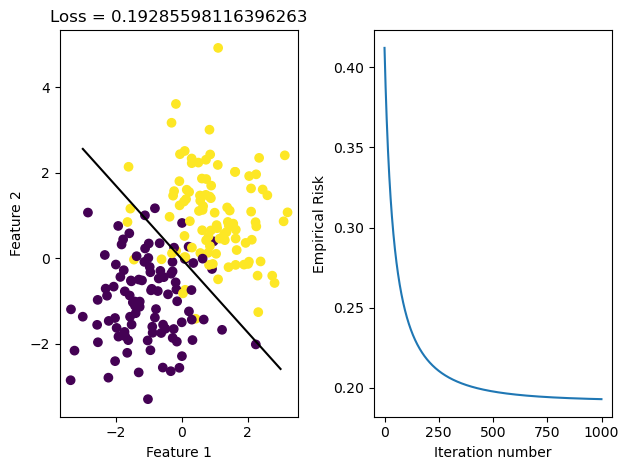

In [14]:
X_ = LR.pad(X)
loss = LR.empirical_risk(X_, y)

fig, axarr = plt.subplots(1, 2)

axarr[0].scatter(X[:,0], X[:,1], c = y)
axarr[0].set(xlabel = "Feature 1", ylabel = "Feature 2", title = f"Loss = {loss}")

f1 = np.linspace(-3, 3, 101)

p = axarr[0].plot(f1, (LR.w[2] - f1*LR.w[0])/LR.w[1], color = "black")

axarr[1].plot(LR.loss_history)
axarr[1].set(xlabel = "Iteration number", ylabel = "Empirical Risk")
plt.tight_layout()

Along with the basic gradient descent method, I have also implemented two more algorithms: stochastic gradient descent with and without momentum. For the momentum method, if the user specifies momentum=True, the momentum variable will set to be 0.8. It helps to consider previous good weights during updating. Here is an example plot showing the evolution of the loss function for the three algorithms:

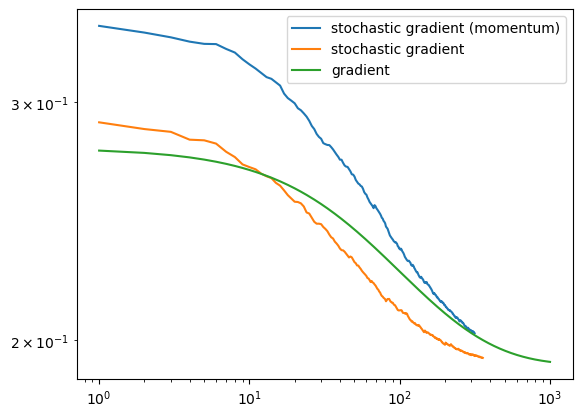

In [15]:
LR = LogisticRegression()
LR.fit_stochastic(X, y, 
                  max_epochs = 1000, 
                  momentum = True, 
                  batch_size = 10, 
                  alpha = .05) 

num_steps = len(LR.loss_history)
plt.plot(np.arange(num_steps) + 1, LR.loss_history, label = "stochastic gradient (momentum)")

LR = LogisticRegression()
LR.fit_stochastic(X, y, 
                  max_epochs = 1000, 
                  momentum = False, 
                  batch_size = 10, 
                  alpha = .1)

num_steps = len(LR.loss_history)
plt.plot(np.arange(num_steps) + 1, LR.loss_history, label = "stochastic gradient")

LR = LogisticRegression()
LR.fit(X, y, alpha = .05, max_epochs = 1000)

num_steps = len(LR.loss_history)
plt.plot(np.arange(num_steps) + 1, LR.loss_history, label = "gradient")

plt.loglog()

legend = plt.legend() 

From the graph, all of those algorithms converge with different speeds. Stochastic gradient descent without momentum and regular gradient descent tend to get a better result comparing to the stochastic gradient descent method with momentum. Meanwhile, both stochastic gradient with and without momentum tend to converge faster comparing the gree line (regular one).

## 2. Perform Experiments

After I have tested and implemented my class, I will perform experiments in three different cases as following:

1. A case in which gradient descent does not converge to a minimizer because the learning rate is too large.
2. A case in which the choice of batch size influences how quickly the algorithm converges.
3. A case in which the use of momentum significantly speeds up convergence.

#### 2.1 Too big alpha

Here I'm setting alpha to be 0.95.

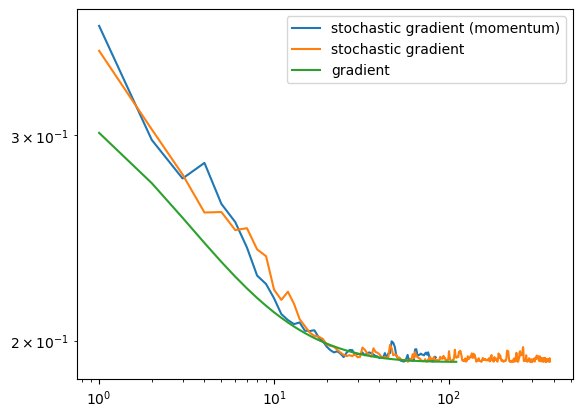

In [16]:
LR = LogisticRegression()
LR.fit_stochastic(X, y, 
                  max_epochs = 1000, 
                  momentum = True, 
                  batch_size = 10, 
                  alpha = .95) 

num_steps = len(LR.loss_history)
plt.plot(np.arange(num_steps) + 1, LR.loss_history, label = "stochastic gradient (momentum)")

LR = LogisticRegression()
LR.fit_stochastic(X, y, 
                  max_epochs = 1000, 
                  momentum = False, 
                  batch_size = 10, 
                  alpha = .95)

num_steps = len(LR.loss_history)
plt.plot(np.arange(num_steps) + 1, LR.loss_history, label = "stochastic gradient")

LR = LogisticRegression()
LR.fit(X, y, alpha = .95, max_epochs = 1000)

num_steps = len(LR.loss_history)
plt.plot(np.arange(num_steps) + 1, LR.loss_history, label = "gradient")

plt.loglog()

legend = plt.legend() 

As we can see from the graph, when alpha is too big (0.95 in this case), our stochastic gradients without momentum, the red line, can't converge properly to a minimizer (it is oscillating!)

#### 2.2 Different batch sizes

I'm going to choose three different batch sizes and compare their performance.

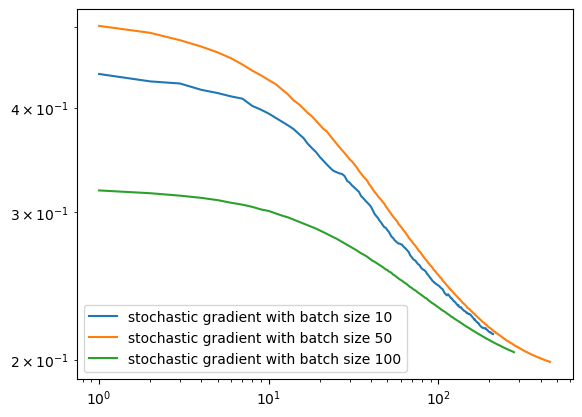

In [17]:
LR = LogisticRegression()
LR.fit_stochastic(X, y, 
                  max_epochs = 1000, 
                  momentum = False, 
                  batch_size = 10, 
                  alpha = .05) 

num_steps = len(LR.loss_history)
plt.plot(np.arange(num_steps) + 1, LR.loss_history, label = "stochastic gradient with batch size 10")

LR = LogisticRegression()
LR.fit_stochastic(X, y, 
                  max_epochs = 1000, 
                  momentum = False, 
                  batch_size = 50, 
                  alpha = .05)

num_steps = len(LR.loss_history)
plt.plot(np.arange(num_steps) + 1, LR.loss_history, label = "stochastic gradient with batch size 50")

LR = LogisticRegression()
LR.fit_stochastic(X, y, 
                  max_epochs = 1000, 
                  momentum = False, 
                  batch_size = 100, 
                  alpha = .05)

num_steps = len(LR.loss_history)
plt.plot(np.arange(num_steps) + 1, LR.loss_history, label = "stochastic gradient with batch size 100")

plt.loglog()

legend = plt.legend() 

After comparing lines with different batch sizes, it appears that the green line with a batch size of 100 converges faster than the other two lines.

#### 2.3 Advantage of momentum

I will show a case in which the use of momentum significantly speeds up convergence.

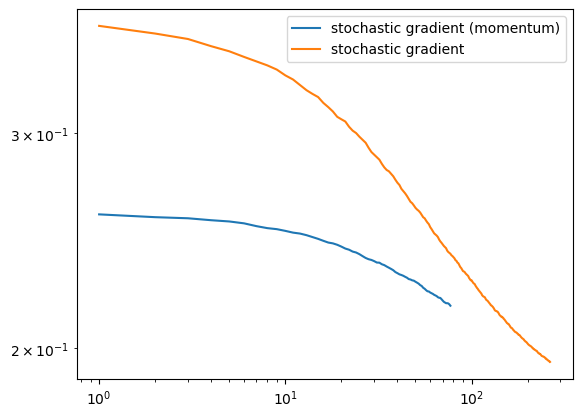

In [18]:
p_features = 3
X, y = make_blobs(n_samples = 200, n_features = p_features - 1, centers =  [(-1, -1), (1, 1)])

LR = LogisticRegression()
LR.fit_stochastic(X, y, 
                  max_epochs = 100, 
                  momentum = True, 
                  batch_size = 20, 
                  alpha = .05) 

num_steps = len(LR.loss_history)
plt.plot(np.arange(num_steps) + 1, LR.loss_history, label = "stochastic gradient (momentum)")

LR = LogisticRegression()
LR.fit_stochastic(X, y, 
                  max_epochs = 100, 
                  momentum = False, 
                  batch_size = 20, 
                  alpha = .05)

num_steps = len(LR.loss_history)
plt.plot(np.arange(num_steps) + 1, LR.loss_history, label = "stochastic gradient")

plt.loglog()

legend = plt.legend() 

Therefore, in this case, the one with momentum significantly improves the converging speed.